# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    print('Downloading the course resources...')
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
else:
    print('Using the existing course folder; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 03</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Embeddings y geometría de tokens</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/03_embeddings_y_geometria_de_tokens_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Cómo pasa un índice discreto a seleccionar una representación vectorial entrenable?

El notebook anterior produjo tokens, índices y batches $X/Y$. Esos índices todavía no son vectores ni contienen significado geométrico por sí mismos. Para que una red neuronal pueda transformar la secuencia, cada índice debe consultar una fila de una tabla entrenable.

Este notebook introduce el puente entre representación discreta y procesamiento vectorial: la tabla de embeddings. La pregunta importante no es solo cómo se obtiene un vector, sino qué significa que ese vector sea un parámetro que puede actualizarse por gradiente.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar por qué un índice identifica un token pero no contiene magnitud ni geometría por sí mismo.
2. Leer una matriz de embeddings como una tabla con una fila entrenable por token del vocabulario.
3. Verificar que `Embedding(x_t)` selecciona una fila y no multiplica por el valor numérico del índice.
4. Identificar qué filas reciben gradiente cuando ciertos tokens aparecen en un batch.
5. Comparar cómo cambia el número de parámetros al variar la dimensión de canales $C$.

## Marco conceptual

Un índice es una llave. Sirve para localizar una fila dentro de una tabla, pero no dice que un token sea mayor, menor, más cercano o más importante que otro. Si el token `a` tiene índice $3$, ese número solo indica una entrada del vocabulario construido en el notebook anterior.

Un embedding es la fila entrenable que se obtiene al usar esa llave. Esa fila es un vector real: un objeto computacional que puede sumarse, proyectarse, compararse y recibir gradiente. La geometría no está en el índice; aparece en la tabla de parámetros $E$ y se vuelve interpretable solo bajo una tarea, un corpus y una pérdida.

Conviene distinguir cuatro niveles:

| Nivel | Pregunta que responde | Objeto |
|---|---|---|
| Token | ¿Qué símbolo aparece? | unidad discreta |
| Índice | ¿Dónde está ese token en el vocabulario? | etiqueta entera |
| Embedding | ¿Qué vector entrenable representa ese token? | fila de $E$ |
| Geometría | ¿Cómo quedan organizados los vectores tras entrenamiento? | relaciones en el espacio de canales |

La visualización 2D que usaremos es pedagógica. Muestra que una fila puede verse como coordenada cuando $C=2$, pero no demuestra significado semántico. Antes del entrenamiento, la cercanía entre puntos suele ser accidental.

## Idea visual del lookup de embeddings

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/03_embeddings_y_geometria_de_tokens.png" alt="Lookup de embeddings desde índices hacia filas entrenables" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura no representa todavía una geometría aprendida del lenguaje. Representa una operación de consulta: un índice apunta a una fila de la matriz $E$, y esa fila es el vector que entra a las capas siguientes. La matriz completa es entrenable; los índices no lo son.

## Formulación matemática

Una matriz de embeddings se define como:

$$
E \in \mathbb{R}^{|\mathcal{V}| \times C}.
$$

Esta ecuación se lee así: la matriz $E$ tiene una fila por token del vocabulario y $C$ columnas o canales por fila. $C$ es la dimensión del vector que usará el modelo para representar cada token.

Para una posición $t$, el embedding se obtiene mediante lookup:

$$
z_t = E[x_t].
$$

Esta ecuación se lee así: el índice $x_t$ selecciona una fila de $E$. Si $x_t=3$, el modelo toma la fila 3; no multiplica el vector por 3 ni interpreta 3 como coordenada.

La misma operación puede escribirse como producto con un vector one-hot:

$$
z_t = \mathrm{onehot}(x_t)^\top E.
$$

Esta ecuación se lee así: el one-hot marca una sola fila con valor 1 y deja las demás en 0. Al multiplicar por $E$, el resultado es exactamente la fila seleccionada. El one-hot no agrega significado semántico; solo hace explícita la selección.

Para un batch completo:

$$
X \in \mathbb{N}^{B \times T} \quad \longrightarrow \quad E[X] \in \mathbb{R}^{B \times T \times C}.
$$

Esta ecuación se lee así: cada entero del tensor de entrada se reemplaza por un vector de $C$ números reales. Por eso aparece la forma $(B,T,C)$.

El número de parámetros de la tabla es:

$$
\#E = |\mathcal{V}| \cdot C.
$$

Esta ecuación se lee así: si el vocabulario crece o si aumenta la dimensión $C$, la tabla de embeddings tiene más parámetros entrenables.


## Traducción tensorial

Antes de embeddings, un batch tiene forma $(B,T)$ y contiene enteros. Después del lookup, el batch tiene forma $(B,T,C)$ y contiene vectores reales entrenables.

El objeto entrenable no es el índice. Lo que cambia durante el entrenamiento son las filas de la matriz $E$ que participan en la pérdida.

## Preparación del entorno

In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.visualizacion as visualizacion
import fundamentos_transformers.embeddings as embeddings

visualizacion = importlib.reload(visualizacion)
embeddings = importlib.reload(embeddings)

configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento 1: selección de filas

Crearemos una tabla de embeddings pequeña, observaremos sus formas y verificaremos que `Embedding(ids)` equivale a seleccionar filas de una matriz. Esta parte es estática para fijar la operación básica antes del explorador interactivo.

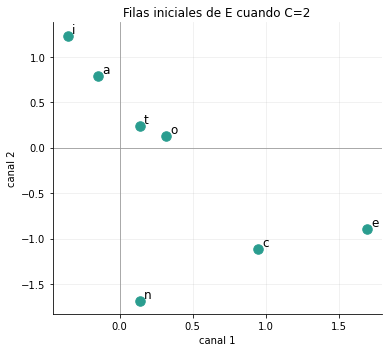

In [2]:
resultado_lookup = embeddings.preparar_experimento_lookup_embeddings(
    vocab=list("atencion"),
    dimension=2,
    indice_consulta=3,
    seed=7,
)

token_a_id = resultado_lookup.token_a_id
id_a_token = resultado_lookup.id_a_token

mostrar_tablas_en_columnas([
    ("Formas del lookup", resultado_lookup.formas),
    ("Selección de una fila", resultado_lookup.seleccion),
], min_width="330px")

display(resultado_lookup.figura)
plt.close(resultado_lookup.figura)


La tabla confirma la operación central: el índice selecciona una fila. `Embedding(idx)`, `E[idx]` y `one_hot @ E` producen el mismo vector; cambian la forma de escribir la selección, no el significado de la operación.

La gráfica 2D no debe leerse como evidencia semántica. Solo muestra que, cuando $C=2$, cada fila de $E$ puede dibujarse como un punto inicial entrenable.


## Explorador interactivo de embeddings

El siguiente explorador permite cambiar el texto, la dimensión $C$, el token consultado y un batch de índices. Observe qué permanece igual y qué cambia: el vocabulario define filas, $C$ define columnas, el lookup produce vectores y las filas consultadas por el batch son las candidatas a recibir gradiente.

In [3]:
import fundamentos_transformers.componentes_interactivos as componentes_interactivos

componentes_interactivos = importlib.reload(componentes_interactivos)

explorador_embeddings = componentes_interactivos.crear_explorador_embeddings(
    dimension_inicial=2,
)
display(explorador_embeddings)

## Experimento 2: filas que reciben gradiente

Ahora haremos una pérdida artificial sobre algunos tokens. El objetivo no es entrenar un buen modelo, sino observar que las filas consultadas por el batch reciben señal de gradiente si la pérdida depende de esos vectores.

In [4]:
resultado_gradientes = embeddings.preparar_experimento_gradientes_embeddings(
    token_a_id,
    id_a_token,
    dimension=3,
    batch_tokens=("a", "t", "a", "n"),
    seed=11,
)

mostrar_tablas_en_columnas([
    ("Batch y pérdida", resultado_gradientes.resumen),
    ("Filas con gradiente", resultado_gradientes.gradientes),
    ("Parámetros al variar C", resultado_gradientes.parametros),
], min_width="280px")


## Interpretación

`Embedding` no interpreta el índice como distancia. Lo usa para elegir una fila. Esa fila contiene parámetros entrenables y recibe gradiente cuando contribuye a la pérdida.

La equivalencia con `one_hot @ E` ayuda a leer la operación: el índice no se trata como número continuo, sino como una llave que activa una fila. En la práctica usamos `Embedding` porque es más directo y eficiente que construir vectores one-hot enormes.

El explorador muestra que aumentar $C$ aumenta el número de parámetros de la tabla y el espacio disponible para representar cada token. Eso no garantiza mejor aprendizaje por sí solo: también aumenta costo y riesgo de ajustar patrones irrelevantes en corpus pequeños.

La tabla de gradientes refuerza un punto operativo: en un paso de entrenamiento no se actualiza necesariamente toda la tabla. Si un token no aparece en el batch y la pérdida no depende de su fila, esa fila no recibe actualización en ese paso. Si un token aparece varias veces, su contribución al gradiente puede acumularse según la pérdida.

En modelos reales, muchas actualizaciones parciales acumuladas van modificando la organización vectorial de la tabla. Por eso la geometría útil de embeddings es una consecuencia del entrenamiento, no una propiedad previa de los índices.


## Verificación de aprendizaje

Use el explorador interactivo y cambie una sola variable: token seleccionado, batch o dimensión $C$. Luego reporte evidencia concreta:

1. qué fila de $E$ selecciona el token elegido;
2. cuál es la forma de $E$ y de $E[\text{batch}]$;
3. cómo se verifica que `Embedding(idx)`, `E[idx]` y `one_hot @ E` representan la misma selección;
4. cómo cambia el número de parámetros al variar $C$;
5. qué filas recibirían gradiente para el batch seleccionado y cuántas veces fueron consultadas;
6. por qué una visualización 2D de embeddings iniciales no demuestra significado semántico.


## Análisis crítico

Los embeddings introducen geometría entrenable, pero esa geometría no viene dada por el vocabulario. La aprende el modelo bajo presión de una pérdida. Por eso no basta mirar una tabla inicial y afirmar que el modelo entiende relaciones entre tokens.

La utilidad del embedding está en permitir que capas posteriores transformen vectores reales. Aun así, una tabla de embeddings de token no sabe en qué posición aparece cada token; para eso hace falta agregar una fuente de información posicional en el siguiente notebook.

## Síntesis

$$
X \in \mathbb{N}^{B \times T} \rightarrow E[X] \in \mathbb{R}^{B \times T \times C}
$$

Esta cadena se lee así: un batch de índices enteros consulta una matriz entrenable y produce un batch de vectores reales con dimensión de canales $C$.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin: 14px 0;">
La idea central es que el índice identifica una fila, pero la fila contiene la representación entrenable. La organización vectorial está en los parámetros, no en el número entero.
</div>

## Preguntas de discusión

1. ¿Por qué no basta usar índices enteros como entrada directa de todas las capas?
2. ¿Qué significa que dos tokens estén cerca en un embedding entrenado?
3. ¿Por qué sería peligroso interpretar una matriz de embeddings aleatoria como semántica?
4. ¿Cómo cambia el costo al aumentar $C$?
5. ¿Qué información falta todavía aunque ya tengamos embeddings de token?

## Continuidad

El siguiente notebook agrega información de posición. Sin esa señal, dos apariciones del mismo token tendrían el mismo vector de contenido aunque ocupen roles distintos en la secuencia.